In [533]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [534]:
# Load the dataset
df = pd.read_csv("japan_birth_statistics_1899_2023.csv")

# Display the first 5 rows
df.head()

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
0,2023,727288,372603,354685,6.0,105.1,1.20
1,2022,770759,395257,375502,6.3,105.3,1.26
2,2021,811622,415903,395719,6.6,105.1,1.30
3,2020,840835,430713,410122,6.8,105.0,1.33
4,2019,865239,443430,421809,7.0,105.1,1.36


In [535]:
df.tail()

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
117,1903,1489816,763806,726010,32.7,105.2,NaN
118,1902,1510835,773296,737539,33.6,104.8,NaN
119,1901,1501591,769494,732097,33.9,105.1,NaN
120,1900,1420534,727916,692618,32.4,105.1,NaN
121,1899,1386981,713442,673539,32.0,105.9,NaN


# Data Inspection

In [536]:
# Check shape of dataset
print("Shape of dataset:", df.shape)

# Show column names
print("\nColumns:")
print(df.columns.tolist())

# Display first 10 rows
print("\nFirst 10 rows:")
print(df.head(10))

Shape of dataset: (122, 7)

Columns:
['year', 'total_births', 'male_births', 'female_births', 'crude_birth_rate', 'sex_ratio_at_birth', 'total_fertility_rate']

First 10 rows:
   year  total_births  male_births  female_births  crude_birth_rate  \
0  2023        727288       372603         354685               6.0   
1  2022        770759       395257         375502               6.3   
2  2021        811622       415903         395719               6.6   
3  2020        840835       430713         410122               6.8   
4  2019        865239       443430         421809               7.0   
5  2018        918400       470851         447549               7.4   
6  2017        946146       484478         461668               7.6   
7  2016        977242       502012         475230               7.8   
8  2015       1005721       515468         490253               8.0   
9  2014       1003609       515572         488037               8.0   

   sex_ratio_at_birth  total_fertility_rat

In [537]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  122 non-null    int64  
 1   total_births          122 non-null    int64  
 2   male_births           122 non-null    int64  
 3   female_births         122 non-null    int64  
 4   crude_birth_rate      122 non-null    float64
 5   sex_ratio_at_birth    122 non-null    float64
 6   total_fertility_rate  77 non-null     float64
dtypes: float64(3), int64(4)
memory usage: 6.8 KB


In [538]:
df.describe()

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
count,122.000000,1.220000e+02,1.220000e+02,1.220000e+02,122.000000,122.000000,77.000000
mean,1961.393443,1.619319e+06,8.304865e+05,7.888323e+05,20.824590,105.310656,1.860779
std,36.585812,4.392864e+05,2.249261e+05,2.144170e+05,10.534323,0.858387,0.696069
min,1899.000000,7.272880e+05,3.726030e+05,3.546850e+05,6.000000,102.700000,1.200000
25%,1929.250000,1.212138e+06,6.233448e+05,5.887932e+05,9.825000,104.900000,1.390000
50%,1962.500000,1.656495e+06,8.494710e+05,8.058480e+05,18.600000,105.300000,1.720000
75%,1992.750000,1.985486e+06,1.014098e+06,9.673500e+05,32.375000,105.800000,2.050000
max,2023.000000,2.696638e+06,1.380008e+06,1.316630e+06,36.200000,108.700000,4.540000


In [539]:
df.isnull().sum()

year                     0
total_births             0
male_births              0
female_births            0
crude_birth_rate         0
sex_ratio_at_birth       0
total_fertility_rate    45
dtype: int64

In [540]:
duplicates = df.duplicated().sum()
duplicates

0

In [541]:
# Check if male_births + female_births equals total_births
df["birth_difference"] = (df["male_births"] + df["female_births"]) - df["total_births"]

print("Rows with inconsistencies in total_births:")
print(df[df["birth_difference"] != 0][["year", "total_births", "male_births", "female_births", "birth_difference"]])

Rows with inconsistencies in total_births:
    year  total_births  male_births  female_births  birth_difference
85  1935       2190704      1122867        1067836                -1
90  1930       2085101      1069551        1015549                -1
94  1926       2104405      1081793        1022611                -1


# Data Cleaning

In [542]:
# Make a copy of the original dataset
clean_df = df.copy()

# Sort by year first before interpolation
clean_df = clean_df.sort_values("year").reset_index(drop=True)

# Fill missing values in total_fertility_rate using interpolation
clean_df["total_fertility_rate"] = (
    clean_df["total_fertility_rate"]
    .interpolate(method="linear")
    .bfill()
    .ffill()
)

clean_df.isnull().sum()

year                    0
total_births            0
male_births             0
female_births           0
crude_birth_rate        0
sex_ratio_at_birth      0
total_fertility_rate    0
birth_difference        0
dtype: int64

In [543]:
# Recalculate total_births from male_births + female_births
clean_df["total_births"] = clean_df["male_births"] + clean_df["female_births"]

# Recheck consistency
clean_df["birth_difference"] = (clean_df["male_births"] + clean_df["female_births"]) - clean_df["total_births"]

print("Remaining inconsistencies after correction:")
print(clean_df[clean_df["birth_difference"] != 0][["year", "total_births", "male_births", "female_births", "birth_difference"]])

Remaining inconsistencies after correction:
Empty DataFrame
Columns: [year, total_births, male_births, female_births, birth_difference]
Index: []


In [544]:
# Drop helper column after checking
clean_df = clean_df.drop(columns=["birth_difference"])

# Data Preparation

In [545]:
# Features and target
X = clean_df[["year", "crude_birth_rate", "sex_ratio_at_birth", "total_fertility_rate"]]
y = clean_df["total_births"]

In [546]:
# Create train and test sets based on year
train_df = clean_df[(clean_df["year"] >= 1970) & (clean_df["year"] <= 2013)]
test_df = clean_df[clean_df["year"] > 2013]

X_train = train_df[["year", "crude_birth_rate", "sex_ratio_at_birth", "total_fertility_rate"]]
y_train = train_df["total_births"]

X_test = test_df[["year", "crude_birth_rate", "sex_ratio_at_birth", "total_fertility_rate"]]
y_test = test_df["total_births"]

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (44, 4)
Testing set size: (10, 4)


# Model Training

In [547]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Visualization

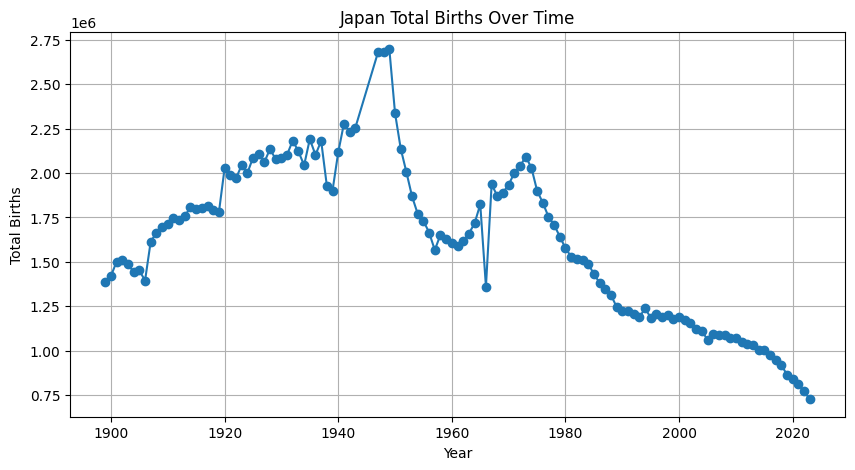

In [548]:
plt.figure(figsize=(10, 5))
plt.plot(clean_df["year"], clean_df["total_births"], marker="o")
plt.title("Japan Total Births Over Time")
plt.xlabel("Year")
plt.ylabel("Total Births")
plt.grid(True)
plt.show()

In [549]:
results_df = pd.DataFrame({
    "year": test_df["year"],
    "actual_total_births": y_test,
    "predicted_total_births": y_pred
})

results_df

,year,actual_total_births,predicted_total_births
112,2014,1003609,9.903595e+05
113,2015,1005721,1.007232e+06
114,2016,977242,9.637907e+05
115,2017,946146,9.747750e+05
116,2018,918400,9.404050e+05
117,2019,865239,9.099454e+05
118,2020,840835,8.951718e+05
119,2021,811622,8.713273e+05
120,2022,770759,8.347407e+05
121,2023,727288,8.177506e+05


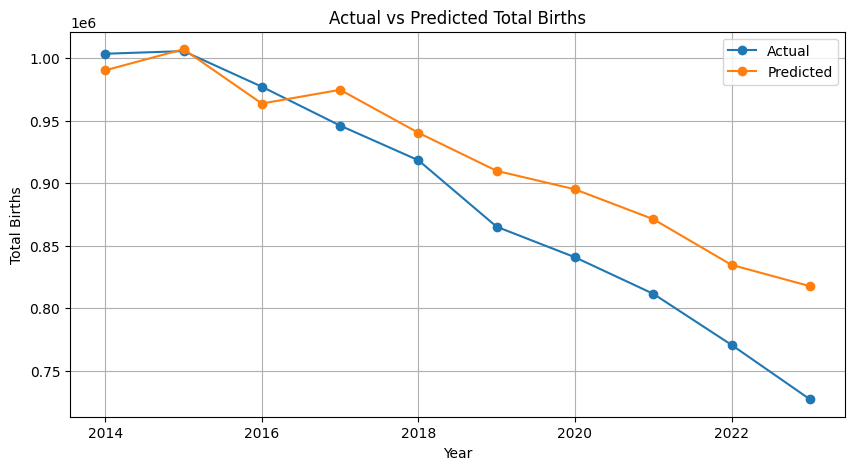

In [550]:
plt.figure(figsize=(10, 5))
plt.plot(results_df["year"], results_df["actual_total_births"], marker="o", label="Actual")
plt.plot(results_df["year"], results_df["predicted_total_births"], marker="o", label="Predicted")
plt.title("Actual vs Predicted Total Births")
plt.xlabel("Year")
plt.ylabel("Total Births")
plt.legend()
plt.grid(True)
plt.show()

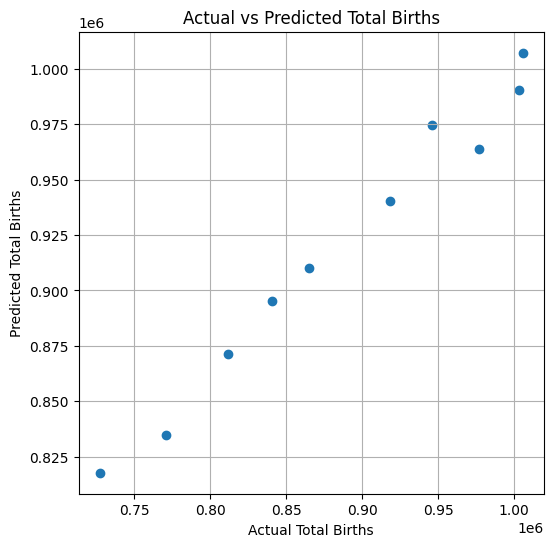

In [551]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.title("Actual vs Predicted Total Births")
plt.xlabel("Actual Total Births")
plt.ylabel("Predicted Total Births")
plt.grid(True)
plt.show()

# Metrics

In [552]:
# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print(f"MAE: {mae:,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"R² Score: {r2:.4f}")

Linear Regression Performance:
MAE: 39,203.83
MSE: 2,245,562,776.06
R² Score: 0.7437
